# Assignment 2

Task 1: a2_regularization.py\
Task 2: Based on previous assignment,
- Use cross-validation to compare 
(i) polynomial, lasso, ridge, normal; 
(ii) with, without momentum;
(iii) stochastic, mini-batch, batch; 
(iv) zero, xavier; 
(v) learning rate of 0.01, 0.001, and 0.0001. 
The comparison should be done in terms of r2 and mse. 
The entire experiment must be performed using ML flow.
- Perform the prediction on the test set using the best model and report the mse and r2. Plot the feature importance graph using the function we have built above.
- Write a short report inside the jupyter notebook discussing your findings, together with some captured screenshots of ML flow, and a final table depicting the comparisons.

## Getting Steps 1, 2 and 3 from Assignment 1

## 1. Imports; Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import sklearn

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("seaborn:", sns.__version__)
print("Matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

NumPy: 2.5.2
pandas: 3.0.5
seaborn: 0.13.2
Matplotlib: 3.11.1
scikit-learn: 1.9.0


In [2]:
# Load data
df = pd.read_csv("../data/Cars.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
# Get info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


In [4]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,8128,2058,Maruti Swift Dzire VDI,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,8128.0,NaN,NaN,NaN,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,NaN,NaN,NaN,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,NaN,NaN,NaN,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
fuel,8128,4,Diesel,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,8128,3,Individual,6766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,8128,2,Manual,7078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,8128,5,First Owner,5289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,7907,393,18.9 kmpl,225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,7907,121,1248 CC,1017,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Note: At this stage, we uploaded libraries and data.\
We also know how many data inside (8128 entries, 13 columns).\
And some Statistical Info.

## 2. Data Cleaning

In [5]:
# Before we do anything, I want to check nulls and duplicates first
print("Original shape:", df.shape)
print("Original missing values:")
display(df.isnull().sum())

print("Original exact duplicates:", df.duplicated().sum())

Original shape: (8128, 13)
Original missing values:


name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

Original exact duplicates: 1202


In [6]:
# As per instructions, we do these steps

# Remove fuel types that use a different mileage unit
df = df.loc[~df["fuel"].isin(["CNG", "LPG"])].copy()

# Map the remaining ordered owner categories
owner_mapping = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5
}
df["owner"] = df["owner"].map(owner_mapping)

# Extract numbers from these column units, invalid or missing strings become NaN.
for column in ["mileage", "engine", "max_power"]:
    df[column] = pd.to_numeric(
        df[column]
        .astype("string")
        .str.extract(
            r"([-+]?\d*\.?\d+)",
            expand=False
        ),
        errors="coerce"
    )

# Rename "name" to "brand" and get only first word
df.rename(columns={'name': 'brand'},inplace=True)
df["brand"] = df["brand"].str.split().str[0]

# Drop unwanted columns
df = df.drop(columns=["torque"])


In [7]:
display(df.head(10))

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.4,1248,74.0,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.7,1497,78.0,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.0,1396,90.0,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.1,1298,88.2,5.0
5,Hyundai,2017,440000,45000,Petrol,Individual,Manual,1,20.14,1197,81.86,5.0
7,Maruti,2001,45000,5000,Petrol,Individual,Manual,2,16.1,796,37.0,4.0
8,Toyota,2011,350000,90000,Diesel,Individual,Manual,1,23.59,1364,67.1,5.0
9,Ford,2013,200000,169000,Diesel,Individual,Manual,1,20.0,1399,68.1,5.0
10,Renault,2014,500000,68000,Diesel,Individual,Manual,2,19.01,1461,108.45,5.0


In [8]:
# Let's see what is wrong with Test Drive Cars(coded as 5)
display(df[df['owner'] == 5])


,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
4383,Volkswagen,2019,1350000,5400,Diesel,Dealer,Manual,5,22.27,1498,108.6,5.0
4950,Audi,2019,6223000,7800,Petrol,Dealer,Automatic,5,15.26,1798,187.74,5.0
4951,Audi,2019,5923000,11500,Petrol,Dealer,Automatic,5,15.26,1798,187.74,5.0
4952,Audi,2019,6523000,23600,Petrol,Dealer,Automatic,5,15.26,1798,187.74,5.0
6220,Honda,2019,2000000,24857,Petrol,Dealer,Automatic,5,16.5,1799,139.46,5.0


In [9]:
# Wow, they are really expensive
# We will delete them as per instruction
df = df.loc[df["owner"] != 5].copy()


In [10]:
# After done as per instructions, we will check nulls and duplicates again
print("After instructions")
print("Shape:", df.shape)
print("Missing values:")
display(df.isnull().sum())

print("Exact duplicates:", df.duplicated().sum())

After instructions
Shape: (8028, 12)
Missing values:


brand              0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          214
engine           214
max_power        208
seats            214
dtype: int64

Exact duplicates: 1220


In [11]:
# We will look at null values and see if we should impute or delete rows

required_columns = ["mileage", "engine", "max_power", "seats"]

missing_mask = df[required_columns].isnull().any(axis=1)
null_rows_df = df.loc[missing_mask].copy()

print("Rows with missing required values:", len(null_rows_df))
print(f"Percentage affected: {missing_mask.mean() * 100:.2f}%")

display(
    null_rows_df[
        required_columns
        + ["brand", "year", "selling_price"]
    ].head(10)
)

Rows with missing required values: 214
Percentage affected: 2.67%


,mileage,engine,max_power,seats,brand,year,selling_price
13,<NA>,<NA>,<NA>,NaN,Maruti,2007,200000
31,<NA>,<NA>,<NA>,NaN,Fiat,2003,70000
78,<NA>,<NA>,<NA>,NaN,Tata,2003,50000
87,<NA>,<NA>,<NA>,NaN,Maruti,2015,475000
119,<NA>,<NA>,<NA>,NaN,Maruti,2010,300000
138,<NA>,<NA>,<NA>,NaN,BMW,2017,2150000
200,<NA>,<NA>,<NA>,NaN,Toyota,2012,235000
206,<NA>,<NA>,<NA>,NaN,Maruti,2003,40000
228,<NA>,<NA>,<NA>,NaN,Maruti,2008,130000
252,<NA>,<NA>,<NA>,NaN,Tata,2005,75000


In [12]:
# As we see, those null values are happening in the same rows.
# And the percentage is very small too, so we will delete those rows.'
df = (
    df.loc[~missing_mask]
    .copy()
    .reset_index(drop=True)
)

In [13]:
# After deleting rows with missing values
print("After deleting nulls:")
print("Shape:", df.shape)
print("Missing values:")
display(df.isnull().sum())

print("Exact duplicates:", df.duplicated().sum())

After deleting nulls:
Shape: (7814, 12)
Missing values:


brand            0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

Exact duplicates: 1207


In [14]:
# Now we will see duplicated rows

# "keep= False" means include first occurance
duplicate_rows_df = df.loc[df.duplicated(keep=False)].copy()

print("Rows involved in duplicate groups:", len(duplicate_rows_df))
print("Duplicate copies to remove:", df.duplicated().sum())

display(
    duplicate_rows_df
    .sort_values(by=list(df.columns))
    .head(10)
)

Rows involved in duplicate groups: 1831
Duplicate copies to remove: 1207


,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
2051,Audi,2014,1850000,76131,Diesel,Individual,Automatic,1,13.22,2967,241.4,5.0
7467,Audi,2014,1850000,76131,Diesel,Individual,Automatic,1,13.22,2967,241.4,5.0
1905,Audi,2017,2825000,22000,Diesel,Dealer,Automatic,1,15.73,1968,174.33,5.0
7035,Audi,2017,2825000,22000,Diesel,Dealer,Automatic,1,15.73,1968,174.33,5.0
123,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
1502,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
1791,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
3100,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
5040,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
7394,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0


Note: Since we only use the first word from "name",\
we may have more duplicates after doing as instructed.

In [15]:
# Delete all those duplicates
df = (
    df.drop_duplicates()
    .reset_index(drop=True)
    .copy()
)

In [16]:
# After deleting duplicated rows
print("After deleting duplicates:")
print("Shape:", df.shape)
print("Exact duplicates:", df.duplicated().sum())

After deleting duplicates:
Shape: (6607, 12)
Exact duplicates: 0


### What we had done: 
- Load original data
- inspect shape, types, missing counts and duplicates
- map owner values
- remove CNG and LPG
- parse mileage
- parse engine
- parse max_power
- extract brand from name
- remove Test Drive Car rows
- drop torque
- inspect missing rows in final retained features
- remove missing rows
- inspect exact duplicates
- remove exact duplicates

## 3. EDA

In [17]:
# Set theme for plot
sns.set_theme(style="whitegrid", context="notebook")

In [18]:
# We will use log function for selling price because it is too big 

df["selling_price_log"] = np.log(df["selling_price"])

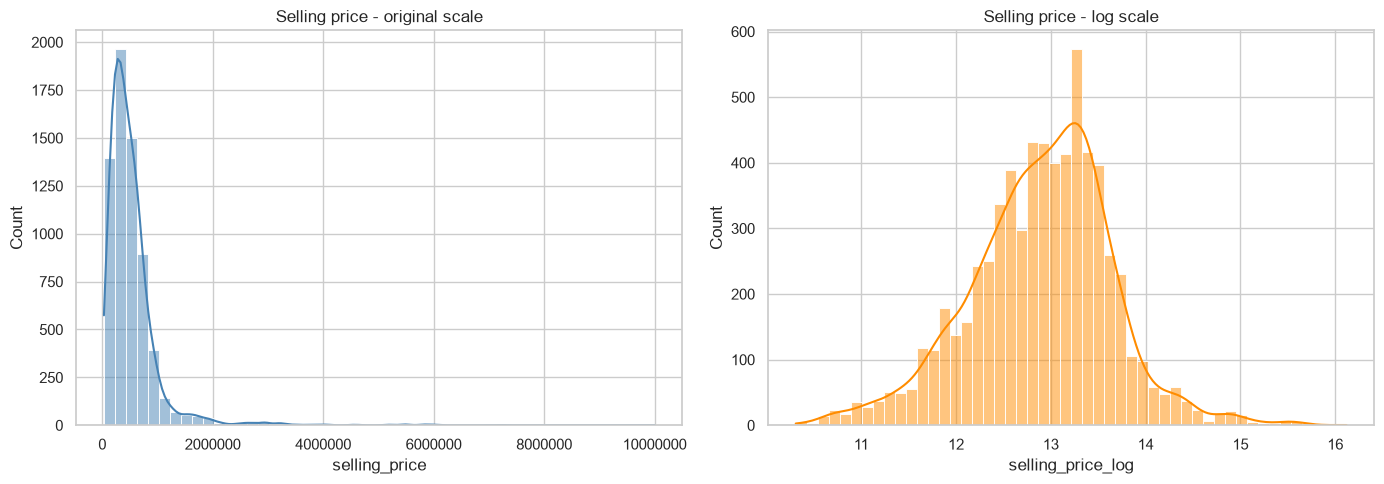

In [19]:
# To show side by side the difference between original selling price and it's log form

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["selling_price"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Selling price - original scale")
axes[0].ticklabel_format(style="plain", axis="x")
sns.histplot(df["selling_price_log"], bins=50, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Selling price - log scale")
plt.tight_layout()
plt.show()

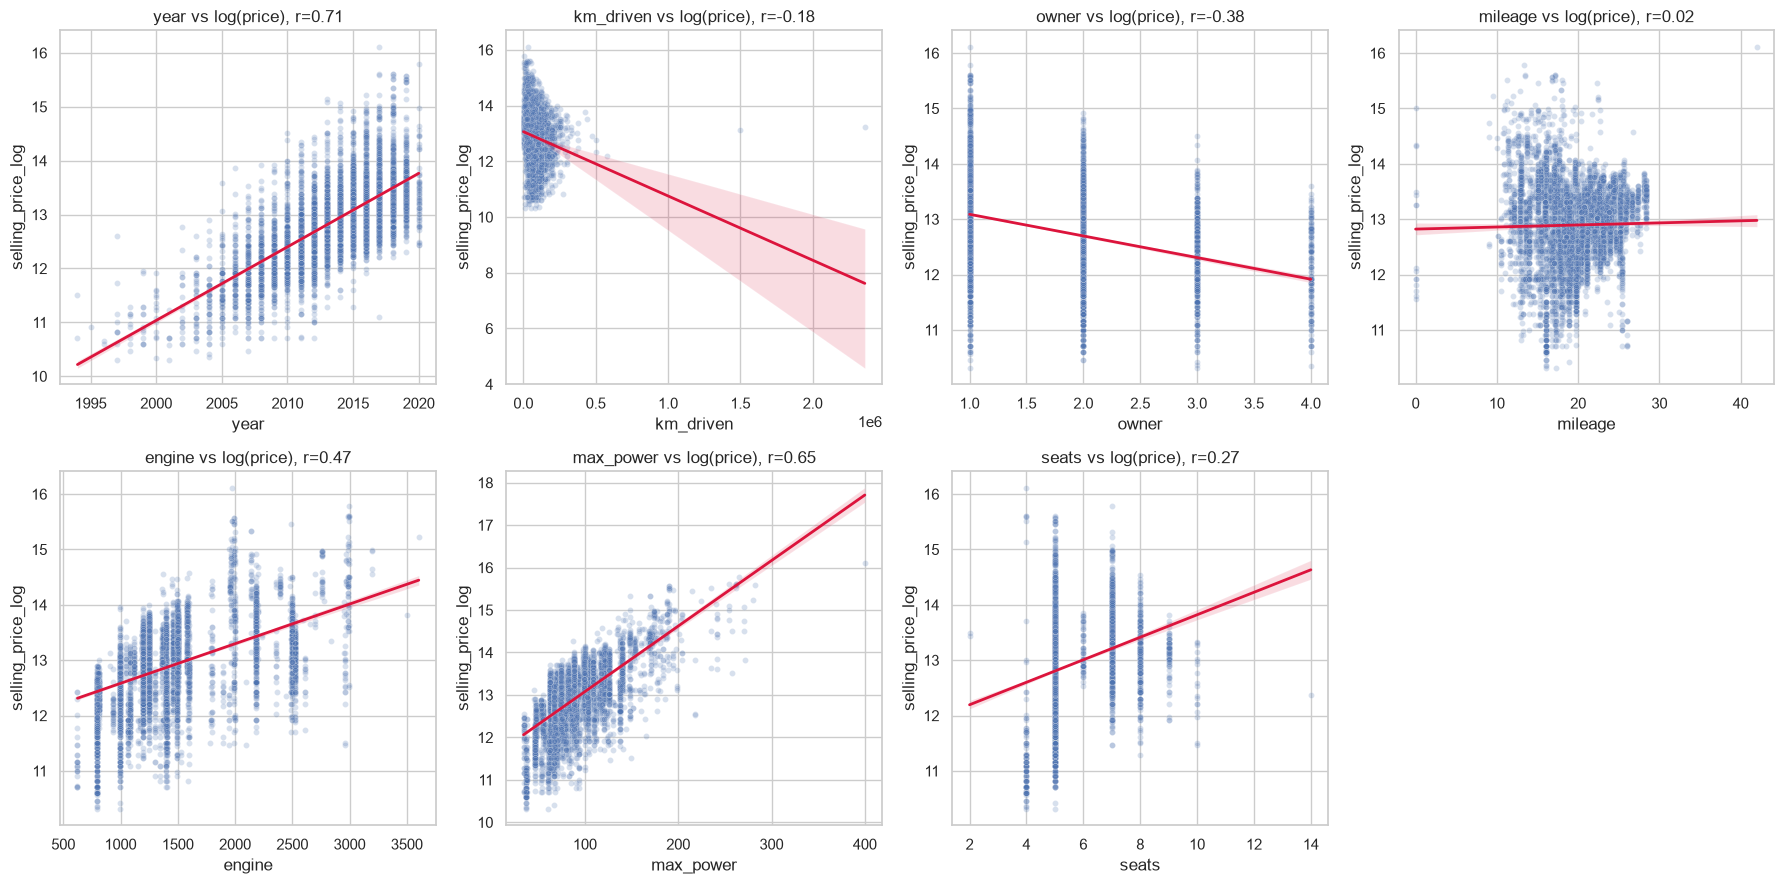

In [20]:
# Scatter and regression plots for numeric features with selling_price_log

numeric_features = ["year", "km_driven", "owner", "mileage", "engine", "max_power", "seats"]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, column in zip(axes.flat, numeric_features):
    sns.scatterplot(data=df, x=column, y="selling_price_log", alpha=0.22, s=18, ax=ax)
    sns.regplot(data=df, x=column, y="selling_price_log", scatter=False,
                color="crimson", line_kws={"linewidth": 2}, ax=ax)
    corr = df[column].corr(df["selling_price_log"])
    ax.set_title(f"{column} vs log(price), r={corr:.2f}")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

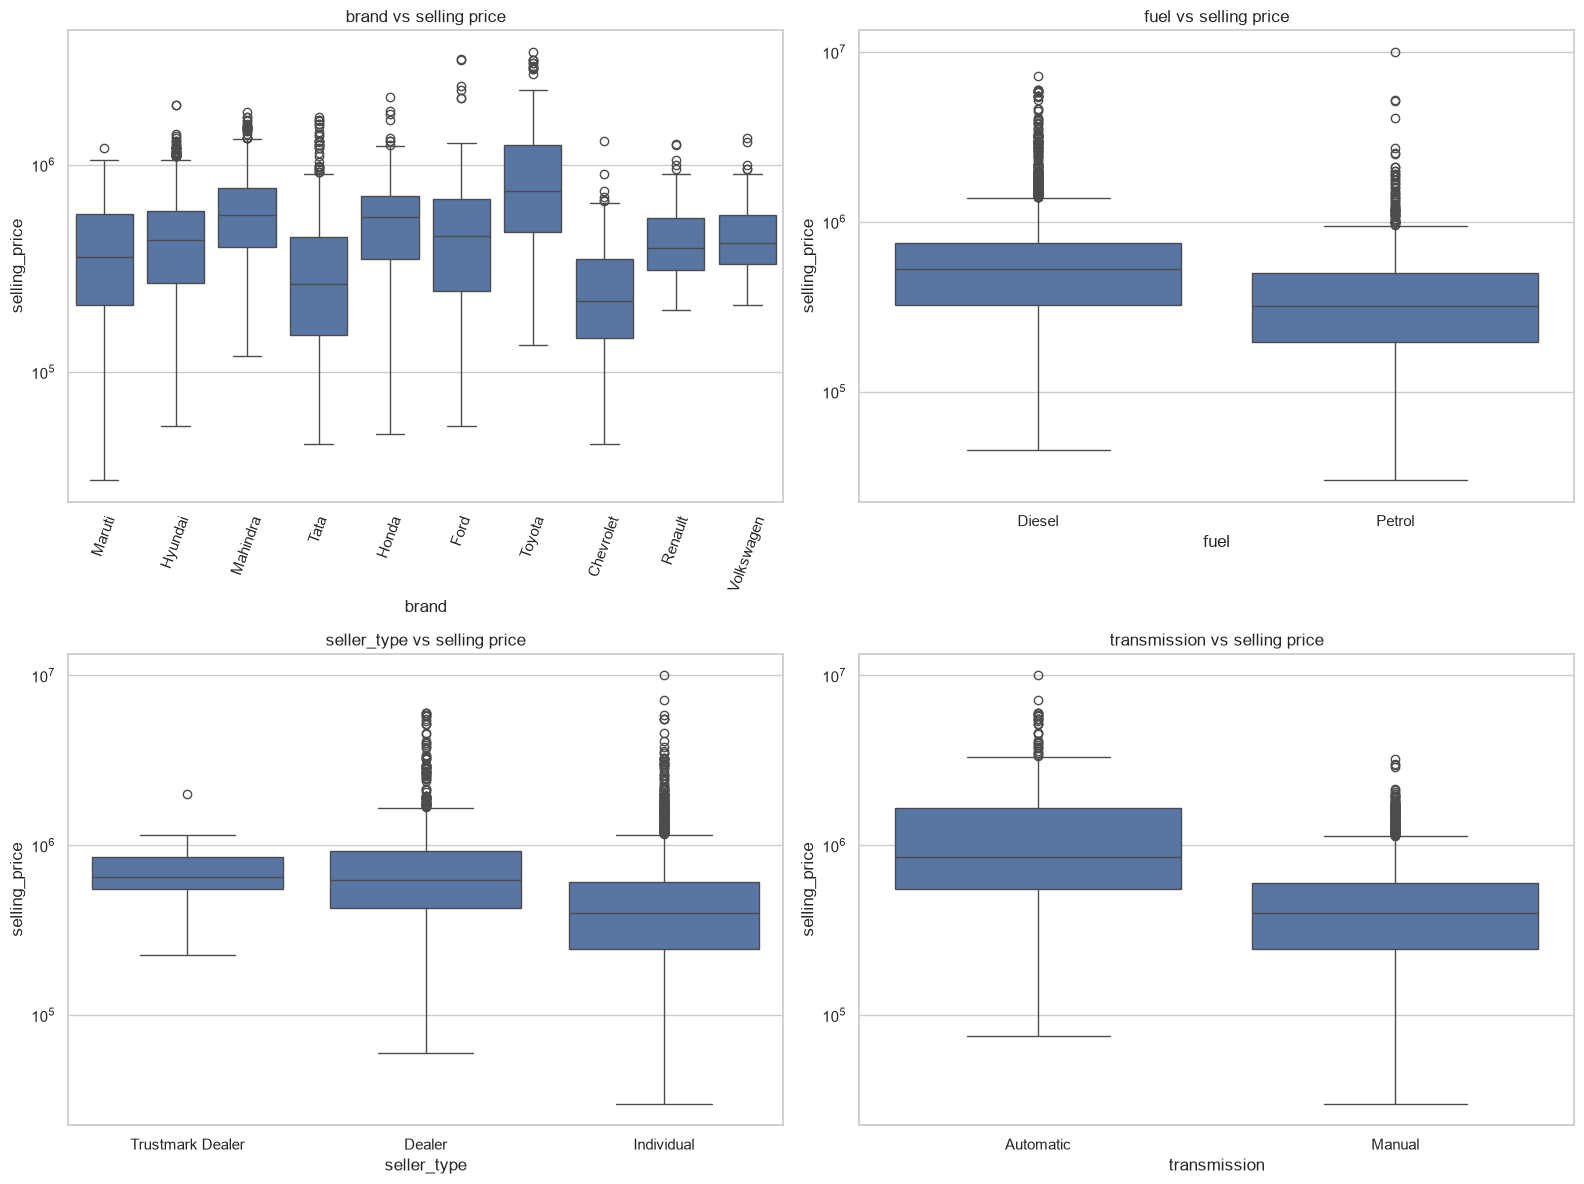

In [21]:
# Box plots for categorical features with selling_price

categorical_features = ["brand", "fuel", "seller_type", "transmission"]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, column in zip(axes.flat, categorical_features):
    if column == "brand":
        # Select the 10 brands with the most observations 
        order = df['brand'].value_counts().index[:10].tolist()
        # To order by median price range
        # order = df.groupby(column)["selling_price"].median().sort_values(ascending=False).index[:10]
        plot_data = df.loc[df[column].isin(order)]
    else:
        order = df.groupby(column)["selling_price"].median().sort_values(ascending=False).index
        plot_data = df
    sns.boxplot(data=plot_data, x=column, y="selling_price", order=order, ax=ax)
    
    # Prices remain in original units, only the visual spacing is logarithmic
    ax.set_yscale("log")
    ax.tick_params(axis="x", rotation=70 if column == "brand" else 0)
    ax.set_title(f"{column} vs selling price")
plt.tight_layout()
plt.show()

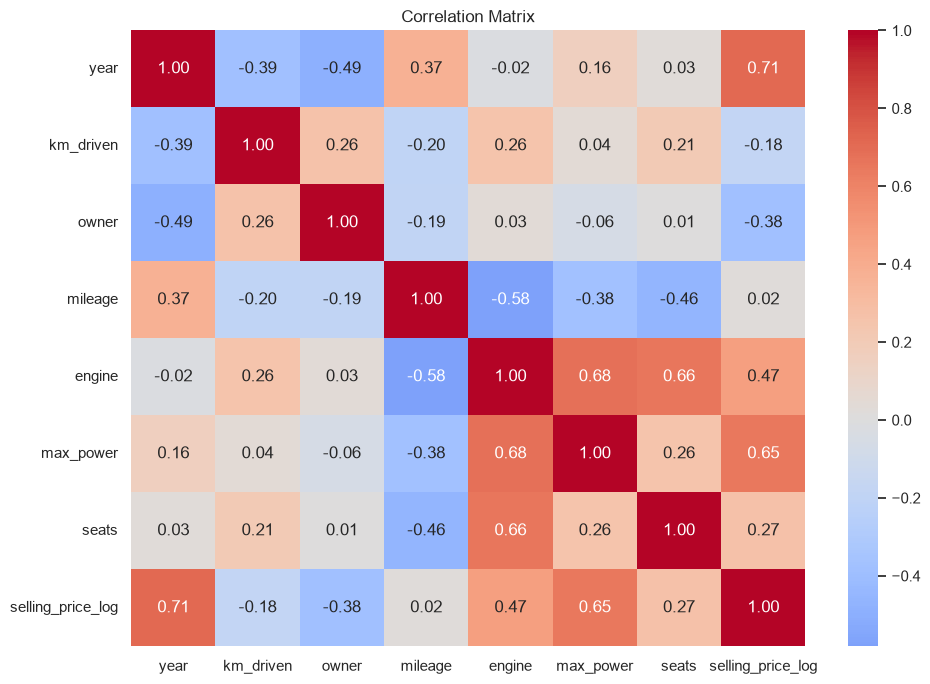

In [22]:
# Checking out heatmap

corr = df[numeric_features + ["selling_price_log"]].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [23]:
# Copy cleaned data for correlation analysis
heatmap_df = df.copy()

# One-hot encode nominal categorical features
heatmap_df = pd.get_dummies(
    heatmap_df,
    columns=[
        "brand",
        "fuel",
        "seller_type",
        "transmission"
    ],
    dtype=int
)

# Remove the original target
heatmap_df = heatmap_df.drop(columns="selling_price")

# Calculate correlations with the log-transformed target
target_correlations = (
    heatmap_df
    .corr(numeric_only=True)["selling_price_log"]
    .drop("selling_price_log")
    .sort_values(key=abs, ascending=False)
)

# Display correlations
display(target_correlations.to_frame("correlation"))

,correlation
year,0.710172
max_power,0.652508
engine,0.471846
owner,-0.381622
fuel_Diesel,0.352996
fuel_Petrol,-0.352996
transmission_Automatic,0.351415
transmission_Manual,-0.351415
seats,0.267909
seller_type_Individual,-0.231506


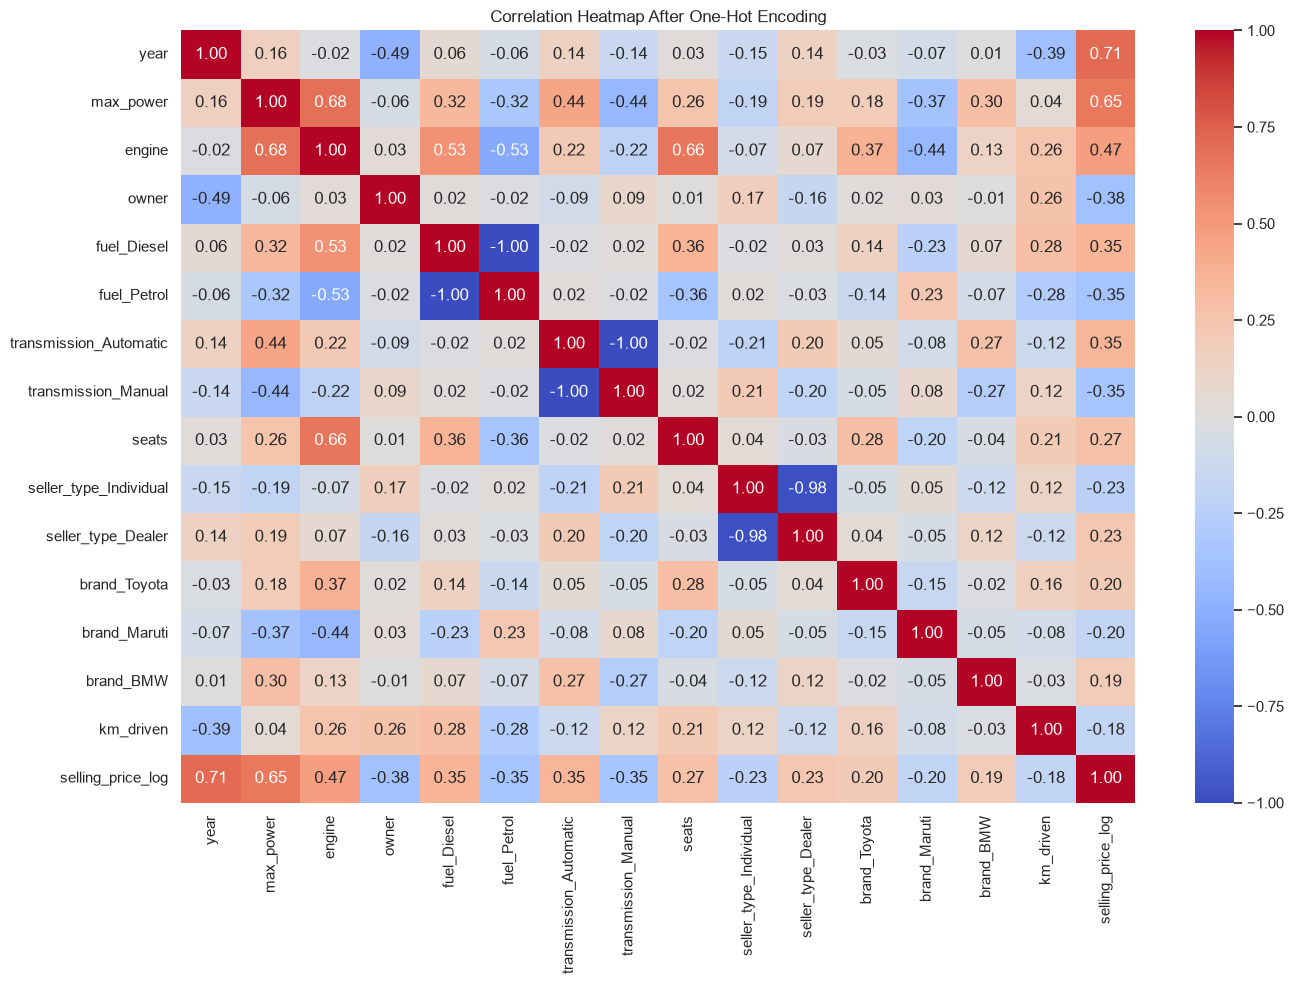

In [24]:
top_feature_names = target_correlations.head(15).index.tolist()

plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_df[
        top_feature_names + ["selling_price_log"]
    ].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap After One-Hot Encoding")
plt.tight_layout()
plt.show()

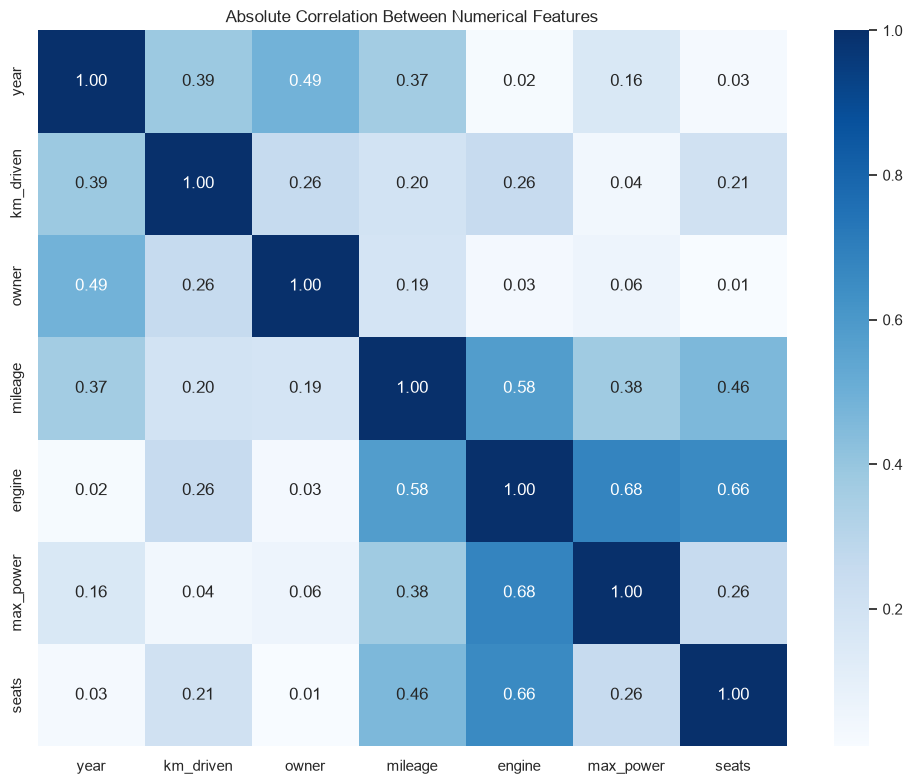

In [25]:


feature_correlation = (df[numeric_features].corr().abs())

plt.figure(figsize=(10, 8))

sns.heatmap(
    feature_correlation,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Absolute Correlation Between Numerical Features")

plt.tight_layout()
plt.show()

### EDA observations

- Log transformation makes the highly right-skewed target substantially more symmetric and reduces the influence of extremely expensive cars.
- Newer model year and greater maximum power generally have positive relationships with selling price; kilometers driven and owner number tend to have negative relationships.
-  No additional predictors were removed solely based on the correlation heatmap. Although some numerical features, particularly engine capacity and maximum power, exhibited correlation with one another, they represent different vehicle characteristics and may provide complementary information to nonlinear models. Features with low marginal correlation were also retained because Pearson correlation only measures linear relationships.

In [26]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand,6607,31,Maruti,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,6607.0,NaN,NaN,NaN,2013.607235,3.901485,1994.0,2011.0,2014.0,2017.0,2020.0
selling_price,6607.0,NaN,NaN,NaN,526943.203421,512208.41043,29999.0,250000.0,421000.0,650000.0,10000000.0
km_driven,6607.0,NaN,NaN,NaN,73424.568185,58828.892938,1000.0,37972.0,68519.0,100000.0,2360457.0
fuel,6607,2,Diesel,3649,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,6607,3,Individual,5920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,6607,2,Manual,6036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,6607.0,NaN,NaN,NaN,1.497805,0.732213,1.0,1.0,1.0,2.0,4.0
mileage,6607.0,<NA>,<NA>,<NA>,19.435396,4.012883,0.0,16.8,19.4,22.32,42.0
engine,6607.0,<NA>,<NA>,<NA>,1435.636295,494.531706,624.0,1197.0,1248.0,1498.0,3604.0


## 4. Modeling

### a2_regularization

In [ ]:
'''
# a2_regularization.py
"""
Task 1: Implementation
Based on: https://github.com/chaklam-silpasuwanchai/Python-for-Machine-Learning/blob/main/01%20-%20Supervised/01%20-%20Regression/03%20-%20Bias-Variance%20Tradeoff%20and%20Regularization.ipynb
a. Add r-squared function.
b. Modify the class such that it allows the user to choose between zeros initialization or xavier.
c. Implement "momentum" so that users can choose whether to use momentum or not.
d. Implement a function inside the class that can plot the feature importance based on coefficients.

"""

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold

class LinearRegression:
    """
    Parameters added for Task 1
    initialization : {"zeros", "xavier"}
        Select zero weights or Xavier-uniform random weights.
    use_momentum : bool
        Whether the update should include the previous gradient step.
    momentum : float
        Momentum coefficient. When enabled, it must be strictly between 0 and 1.
    random_state : int
        Makes Xavier initialization and shuffling reproducible.
    """

    def __init__(
        self,
        regularization,
        lr=0.001,
        method="batch",
        num_epochs=500,
        batch_size=50,
        cv=None,
        initialization="zeros",
        use_momentum=False,
        momentum=0.9,
        random_state=42,
        gradient_clip=None,
        tol=1e-8, # tolerance: training stops when the validation MSE changes by no more than 0.00000001
        verbose=True,
    ):
        # Task 2 uses the descriptive name "mini-batch" in its experiment
        # table, while the original course class used "mini".
        if method == "mini-batch":
            method = "mini"
        if method not in {"batch", "mini", "stochastic"}:
            raise ValueError("method must be 'batch', 'mini'/'mini-batch', or 'stochastic'")
        if initialization not in {"zeros", "xavier"}:
            raise ValueError("initialization must be 'zeros' or 'xavier'")
        if use_momentum and not 0 < momentum < 1:
            raise ValueError("momentum must be strictly between 0 and 1")
        if gradient_clip is not None and gradient_clip <= 0:
            raise ValueError("gradient_clip must be positive or None")
        if not hasattr(regularization, "derivation"):
            raise TypeError(
                "regularization must be a regularization object such as "
                "NoRegularization(), Lasso(l), or Ridge(l), not a string"
            )

        self.lr = lr
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.method = method
        # cv=False is used when an outer experiment loop already performs CV.
        # This avoids accidentally doing nested cross-validation.
        self.cv = (
            KFold(n_splits=5, shuffle=True, random_state=random_state)
            if cv is None
            else cv
        )
        self.regularization = regularization
        self.initialization = initialization
        self.use_momentum = use_momentum
        self.momentum = momentum
        self.random_state = random_state
        self.gradient_clip = gradient_clip
        self.tol = tol
        self.verbose = verbose

    def mse(self, ytrue, ypred):
        # Return mean squared error.
        ytrue = np.asarray(ytrue)
        ypred = np.asarray(ypred)
        return float(np.mean((ypred - ytrue) ** 2))

    def r2(self, ytrue, ypred):
        # Return R-squared, computed as 1 - SSE / SST.
        ytrue = np.asarray(ytrue)
        ypred = np.asarray(ypred)
        sse = np.sum((ytrue - ypred) ** 2)
        sst = np.sum((ytrue - np.mean(ytrue)) ** 2)
        if np.isclose(sst, 0):
            return 0.0
        return float(1 - sse / sst)

    def _initialize_weights(self, number_of_weights):
        """Initialize theta using the option selected by the user."""
        if self.initialization == "zeros":
            return np.zeros(number_of_weights)

        # Xavier-uniform: draw each weight from [-1/sqrt(m), 1/sqrt(m)].
        # Here m is the number of model inputs/weights, including the bias.
        limit = 1.0 / np.sqrt(number_of_weights)
        return self._rng.uniform(-limit, limit, size=number_of_weights)

    def fit(self, X_train, y_train):
        X_train = np.asarray(X_train, dtype=float)
        y_train = np.asarray(y_train, dtype=float).reshape(-1)
        self._rng = np.random.default_rng(self.random_state)
        self.kfold_scores = []
        self.kfold_r2_scores = []

        # Train once on all supplied rows when cross-validation is managed by
        # the caller (as it is in a2_mlflow.py).
        if self.cv is False:
            self.theta = self._initialize_weights(X_train.shape[1])
            self.prev_step = np.zeros_like(self.theta)
            self.loss_history = []
            for _ in range(self.num_epochs):
                self._run_epoch(X_train, y_train)
                self.loss_history.append(self.mse(y_train, self.predict(X_train)))
            return self

        for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):
            X_cross_train = X_train[train_idx].copy()
            y_cross_train = y_train[train_idx].copy()
            X_cross_val = X_train[val_idx]
            y_cross_val = y_train[val_idx]

            self.theta = self._initialize_weights(X_cross_train.shape[1])
            self.prev_step = np.zeros_like(self.theta)
            val_loss_old = np.inf

            for _ in range(self.num_epochs):
                X_cross_train, y_cross_train = self._run_epoch(
                    X_cross_train, y_cross_train
                )

                yhat_val = self.predict(X_cross_val)
                val_loss_new = self.mse(y_cross_val, yhat_val)
                if abs(val_loss_old - val_loss_new) <= self.tol:
                    break
                val_loss_old = val_loss_new

            val_r2 = self.r2(y_cross_val, self.predict(X_cross_val))
            self.kfold_scores.append(val_loss_new)
            self.kfold_r2_scores.append(val_r2)
            if self.verbose:
                print(f"Fold {fold + 1}: MSE={val_loss_new:.6f}, R2={val_r2:.6f}")

        return self

    def _run_epoch(self, X, y):
        """Shuffle once and perform the selected gradient-update strategy."""
        permutation = self._rng.permutation(X.shape[0])
        X = X[permutation]
        y = y[permutation]

        if self.method == "mini":
            for batch_idx in range(0, X.shape[0], self.batch_size):
                self._train(
                    X[batch_idx : batch_idx + self.batch_size],
                    y[batch_idx : batch_idx + self.batch_size],
                )
        elif self.method == "stochastic":
            for row_idx in range(X.shape[0]):
                self._train(X[row_idx : row_idx + 1], y[row_idx : row_idx + 1])
        else:
            self._train(X, y)
        return X, y

    def _train(self, X, y):
        yhat = self.predict(X)
        m = X.shape[0]
        regularization_gradient = self.regularization.derivation(self.theta).copy()
        # The first element is the bias/intercept and should not be penalized.
        regularization_gradient[0] = 0
        grad = (1 / m) * X.T @ (yhat - y) + regularization_gradient

        # Polynomial and stochastic configurations can create unusually large
        # gradients. Optional norm clipping keeps the required learning-rate
        # grid numerically stable without changing the direction of the update.
        grad_norm = np.linalg.norm(grad)
        if self.gradient_clip is not None and grad_norm > self.gradient_clip:
            grad = grad * (self.gradient_clip / grad_norm)

        # Momentum follows the pseudocode supplied in the assignment.
        step = self.lr * grad
        if self.use_momentum:
            self.theta = self.theta - step + self.momentum * self.prev_step
        else:
            self.theta = self.theta - step
        self.prev_step = step
        return self.mse(y, yhat)

    def predict(self, X):
        return np.asarray(X) @ self.theta

    def _coef(self):
        return self.theta[1:]

    def _bias(self):
        return self.theta[0]

    def plot_feature_importance(self, feature_names, top_n=None, ax=None):
        """
        Plot signed coefficients, ordered by their absolute magnitudes.

        Coefficient magnitudes are comparable only when the input features use
        the same units or have been scaled before fitting.
        """
        if not hasattr(self, "theta"):
            raise ValueError("Fit the model before plotting feature importance")

        feature_names = np.asarray(feature_names, dtype=object)
        coefficients = self._coef()
        if len(feature_names) != len(coefficients):
            raise ValueError("feature_names must match the number of non-bias coefficients")

        count = len(coefficients) if top_n is None else min(top_n, len(coefficients))
        order = np.argsort(np.abs(coefficients))[-count:]
        colors = np.where(coefficients[order] >= 0, "#15803d", "#dc2626")

        if ax is None:
            _, ax = plt.subplots(figsize=(9, 6))
        ax.barh(feature_names[order], coefficients[order], color=colors)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Coefficient value (features must be scaled)")
        ax.set_title("Feature importance based on coefficient magnitude")
        return ax


class NoRegularization:
    # No penalty; useful when ordinary linear regression is required.

    def __call__(self, theta):
        return 0.0

    def derivation(self, theta):
        return np.zeros_like(theta)


class Lasso:
    def __init__(self, l):
        self.l = l

    def __call__(self, theta):
        return self.l * np.sum(np.abs(theta))

    def derivation(self, theta):
        return self.l * np.sign(theta)


class Ridge:
    def __init__(self, l):
        self.l = l

    def __call__(self, theta):
        return self.l * np.sum(np.square(theta))

    def derivation(self, theta):
        return self.l * 2 * theta


class Elastic:
    def __init__(self, l, l_ratio):
        self.l = l
        self.l_ratio = l_ratio

    def __call__(self, theta):
        l1 = self.l_ratio * self.l * np.sum(np.abs(theta))
        l2 = (1 - self.l_ratio) * self.l * np.sum(np.square(theta))
        return l1 + l2

    def derivation(self, theta):
        l1 = self.l * self.l_ratio * np.sign(theta)
        l2 = 2 * self.l * (1 - self.l_ratio) * theta
        return l1 + l2

class LassoRegression(LinearRegression):
    def __init__(self, method="batch", lr=0.001, l=0.01, **kwargs):
        super().__init__(Lasso(l), lr=lr, method=method, **kwargs)


class RidgeRegression(LinearRegression):
    def __init__(self, method="batch", lr=0.001, l=0.01, **kwargs):
        super().__init__(Ridge(l), lr=lr, method=method, **kwargs)


class ElasticRegression(LinearRegression):
    def __init__(self, method="batch", lr=0.001, l=0.01, l_ratio=0.5, **kwargs):
        super().__init__(Elastic(l, l_ratio), lr=lr, method=method, **kwargs)


'''

### a2_mlflow

In [ ]:
# a2_mlflow.py
'''
from __future__ import annotations

from itertools import product
from pathlib import Path
import json
import os
import sys

# Silence an unrelated MLflow GenAI helper message before importing MLflow.
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")

import joblib
import mlflow
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

ROOT_DIR = Path(__file__).resolve().parent.parent
DATA_DIR = ROOT_DIR / "data"
# OUTPUT_DIR = ROOT_DIR / "assignment2" / "task2"
MODEL_DIR = ROOT_DIR / "models"

from a2_regularization import LinearRegression, Lasso, NoRegularization, Ridge


RANDOM_STATE = 42
CV_EPOCHS = 12
FINAL_EPOCHS = 60
BATCH_SIZE = 128
REGULARIZATION_STRENGTH = 0.001
GRADIENT_CLIP = 10.0
NUMERIC = ["year", "km_driven", "owner", "mileage", "engine", "max_power", "seats"]
CATEGORICAL = ["brand", "fuel", "seller_type", "transmission"]


def make_regularization(name):
    """Convert the grid's readable label into the object required by the class."""
    regularizers = {
        "normal": NoRegularization,
        "lasso": lambda: Lasso(REGULARIZATION_STRENGTH),
        "ridge": lambda: Ridge(REGULARIZATION_STRENGTH),
    }
    try:
        return regularizers[name]()
    except KeyError as exc:
        raise ValueError(f"Unknown regularization: {name}") from exc


def add_intercept(X):
    """Add the leading column of ones expected by the course regression class."""
    X = np.asarray(X, dtype=float)
    return np.column_stack([np.ones(X.shape[0]), X])


def clean_data(frame):
    # Repeat the attached Assignment 1 notebook's cleaning order exactly.
    data = frame.copy()
    data = data.loc[~data["fuel"].isin(["CNG", "LPG"])]
    data["owner"] = data["owner"].map(
        {
            "First Owner": 1,
            "Second Owner": 2,
            "Third Owner": 3,
            "Fourth & Above Owner": 4,
            "Test Drive Car": 5,
        }
    )
    for column in ["mileage", "engine", "max_power"]:
        data[column] = pd.to_numeric(
            data[column].astype("string").str.extract(r"([-+]?\d*\.?\d+)", expand=False),
            errors="coerce",
        )
    data = data.rename(columns={"name": "brand"})
    data["brand"] = data["brand"].astype("string").str.split().str[0]
    data = data.drop(columns=["torque"])
    data = data.loc[data["owner"] != 5].copy()

    # Deleted the small group of rows missing any of these four fields.
    required_columns = ["mileage", "engine", "max_power", "seats"]
    missing_mask = data[required_columns].isnull().any(axis=1)
    data = data.loc[~missing_mask].copy().reset_index(drop=True)

    # Deduplication happens after parsing and brand extraction in A1.
    return data.drop_duplicates().reset_index(drop=True).copy()


def make_preprocessor(polynomial=False):
    """Create fold-local imputation, scaling, encoding, and optional polynomial terms."""
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ]
    if polynomial:
        numeric_steps.extend(
            [
                ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
                ("polynomial_scaler", StandardScaler()),
            ]
        )
    return ColumnTransformer(
        [
            ("numeric", Pipeline(numeric_steps), NUMERIC),
            (
                "categorical",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                    ]
                ),
                CATEGORICAL,
            ),
        ]
    )


def build_grid():
    """Return the exact 4 × 2 × 3 × 2 × 3 factorial design."""
    model_specs = {
        "normal": (False, "normal"),
        "polynomial": (True, "normal"),
        "lasso": (False, "lasso"),
        "ridge": (False, "ridge"),
    }
    configurations = []
    for model_type, use_momentum, method, initialization, learning_rate in product(
        model_specs,
        [False, True],
        ["stochastic", "mini-batch", "batch"],
        ["zeros", "xavier"],
        [0.01, 0.001, 0.0001],
    ):
        polynomial, regularization = model_specs[model_type]
        configurations.append(
            {
                "model_type": model_type,
                "polynomial": polynomial,
                "regularization": regularization,
                "use_momentum": use_momentum,
                "method": method,
                "initialization": initialization,
                "learning_rate": learning_rate,
            }
        )
    assert len(configurations) == 144
    return configurations


def evaluate_config(X, y, config, splits):
    """Evaluate one configuration on the same five folds used by every run."""
    fold_rows = []
    for fold, (train_idx, validation_idx) in enumerate(splits, start=1):
        preprocessor = make_preprocessor(config["polynomial"])
        x_train = add_intercept(preprocessor.fit_transform(X.iloc[train_idx]))
        x_validation = add_intercept(preprocessor.transform(X.iloc[validation_idx]))
        y_train = y.iloc[train_idx].to_numpy()
        y_validation = y.iloc[validation_idx].to_numpy()

        target_mean = y_train.mean()
        target_scale = y_train.std()
        model = LinearRegression(
            regularization=make_regularization(config["regularization"]),
            lr=config["learning_rate"],
            method=config["method"],
            initialization=config["initialization"],
            use_momentum=config["use_momentum"],
            momentum=0.9,
            num_epochs=CV_EPOCHS,
            batch_size=BATCH_SIZE,
            random_state=RANDOM_STATE + fold,
            gradient_clip=GRADIENT_CLIP,
            cv=False,
            verbose=False,
        ).fit(x_train, (y_train - target_mean) / target_scale)

        prediction = model.predict(x_validation) * target_scale + target_mean
        fold_mse = model.mse(y_validation, prediction)
        fold_r2 = model.r2(y_validation, prediction)
        fold_rows.append({"fold": fold, "mse": fold_mse, "r2": fold_r2})
        mlflow.log_metric("fold_mse", fold_mse, step=fold)
        mlflow.log_metric("fold_r2", fold_r2, step=fold)

    fold_frame = pd.DataFrame(fold_rows)
    return {
        "cv_mse": float(fold_frame["mse"].mean()),
        "cv_mse_std": float(fold_frame["mse"].std(ddof=0)),
        "cv_r2": float(fold_frame["r2"].mean()),
        "cv_r2_std": float(fold_frame["r2"].std(ddof=0)),
    }


def fit_best_model(X_train, y_train, X_test, y_test, best):
    """Refit the selected configuration on all training data and evaluate once on test data."""
    preprocessor = make_preprocessor(bool(best["polynomial"]))
    x_train = add_intercept(preprocessor.fit_transform(X_train))
    x_test = add_intercept(preprocessor.transform(X_test))
    target_mean = float(y_train.mean())
    target_scale = float(y_train.std())

    model = LinearRegression(
        regularization=make_regularization(best["regularization"]),
        lr=float(best["learning_rate"]),
        method=best["method"],
        initialization=best["initialization"],
        use_momentum=bool(best["use_momentum"]),
        momentum=0.9,
        num_epochs=FINAL_EPOCHS,
        batch_size=BATCH_SIZE,
        random_state=RANDOM_STATE,
        gradient_clip=GRADIENT_CLIP,
        cv=False,
        verbose=False,
    ).fit(x_train, (y_train.to_numpy() - target_mean) / target_scale)

    predicted_log_price = model.predict(x_test) * target_scale + target_mean
    actual_price = np.exp(y_test.to_numpy())
    predicted_price = np.exp(predicted_log_price)
    test_metrics = {
        "test_mse_log": model.mse(y_test.to_numpy(), predicted_log_price),
        "test_r2_log": model.r2(y_test.to_numpy(), predicted_log_price),
        "test_mse_price": model.mse(actual_price, predicted_price),
        "test_rmse_price": float(np.sqrt(model.mse(actual_price, predicted_price))),
        "test_r2_price": model.r2(actual_price, predicted_price),
    }
    bundle = {
        "preprocessor": preprocessor,
        "model": model,
        "target_mean": target_mean,
        "target_scale": target_scale,
        "feature_names": preprocessor.get_feature_names_out().tolist(),
        "best_config": best,
        "test_metrics": test_metrics,
    }
    return bundle


def main():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    data = clean_data(pd.read_csv(DATA_DIR / "Cars.csv"))
    X = data[NUMERIC + CATEGORICAL]
    # Assignment 1 modeled log selling price, so Task 2 retains the same target.
    y = np.log(data["selling_price"].astype(float))
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE
    )

    configurations = build_grid()
    splits = list(KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X_train))

    os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"
    tracking_db = DATA_DIR / "a2_mlflow.db"
    mlflow.set_tracking_uri(f"sqlite:///{tracking_db}")
    mlflow.set_experiment("A2 Task 2 - Based on A1 Car Price Notebook")
    rows = []

    for run_number, config in enumerate(configurations, start=1):
        # Training and validation happen inside the MLflow run, not before it.
        with mlflow.start_run(run_name=f"{config['model_type']}-{run_number:03d}"):
            mlflow.log_params(
                config
                | {
                    "folds": 5,
                    "epochs": CV_EPOCHS,
                    "batch_size": BATCH_SIZE,
                    "regularization_strength": REGULARIZATION_STRENGTH,
                    "gradient_clip": GRADIENT_CLIP,
                    "target": "log_selling_price",
                }
            )
            metrics = evaluate_config(X_train, y_train, config, splits)
            mlflow.log_metrics(metrics)

        row = {**config, **metrics}
        rows.append(row)
        print(
            f"[{run_number:03d}/144] R2={metrics['cv_r2']:.4f} "
            f"MSE={metrics['cv_mse']:.5f} {config}"
        )

    results = pd.DataFrame(rows).sort_values(
        ["cv_r2", "cv_mse"], ascending=[False, True]
    )
    results.to_csv(DATA_DIR / "a2_experiment_results.csv", index=False)
    best = results.iloc[0].to_dict()
    bundle = fit_best_model(X_train, y_train, X_test, y_test, best)

    joblib.dump(bundle, MODEL_DIR / "best_a2_model.joblib")
    summary = {"best_config": best, "test_metrics": bundle["test_metrics"]}
    (DATA_DIR / "a2_best_model_summary.json").write_text(
        json.dumps(summary, indent=2, default=str)
    )
    print("BEST", json.dumps(summary, indent=2, default=str))


if __name__ == "__main__":
    main()
'''

### Task2
The full Task 2 experiment was run by `a2_mlflow.py`. It compared all **144 configurations** using the same five shuffled folds. This notebook loads those completed results rather than training the 144 configurations again. This prevents duplicate MLflow runs and keeps the notebook focused on analysis, test-set evaluation, and reporting.

The target is `log(selling_price)`, consistent with Assignment 1. MSE and R² reported during cross-validation are therefore on the log-price scale.

In [38]:
from pathlib import Path
import json
import sys
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Find the project root whether Jupyter starts here or inside notebooks/.
current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate
    for candidate in [current_dir, *current_dir.parents]
    if (candidate / 'data' / 'Cars.csv').exists()
)
NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

RESULTS_PATH = PROJECT_ROOT / 'data' / 'a2_experiment_results.csv'
SUMMARY_PATH = PROJECT_ROOT / 'data' / 'a2_best_model_summary.json'
MODEL_PATH = PROJECT_ROOT / 'models' / 'best_a2_model.joblib'
MLFLOW_DB_PATH = PROJECT_ROOT / 'data' / 'a2_mlflow.db'

required_artifacts = [RESULTS_PATH, SUMMARY_PATH, MODEL_PATH, MLFLOW_DB_PATH]
missing_artifacts = [str(path) for path in required_artifacts if not path.exists()]
if missing_artifacts:
    raise FileNotFoundError(
        'Run notebooks/a2_mlflow.py first. Missing: ' + ', '.join(missing_artifacts)
    )

results = pd.read_csv(RESULTS_PATH).sort_values(
    ['cv_r2', 'cv_mse'], ascending=[False, True]
).reset_index(drop=True)
results.insert(0, 'rank', np.arange(1, len(results) + 1))
summary = json.loads(SUMMARY_PATH.read_text())

# Import the class before unpickling the saved custom model.
from a2_regularization import LinearRegression
bundle = joblib.load(MODEL_PATH)

print(f'Loaded {len(results)} experiment configurations.')
print('MLflow database:', MLFLOW_DB_PATH)
print('Saved model:', MODEL_PATH)

Loaded 144 experiment configurations.
MLflow database: /Users/krown/AIT/ML/Assignments/A1_Car_Prediction/data/a2_mlflow.db
Saved model: /Users/krown/AIT/ML/Assignments/A1_Car_Prediction/models/best_a2_model.joblib


### 4.1 Experimental design

The experiment uses a fixed 80/20 train-test split (`random_state=42`). Only the 80% training portion participates in five-fold cross-validation. Every configuration uses the same folds. Preprocessing is fitted separately inside each training fold to avoid validation leakage.

The factorial comparison contains:

- model type: normal, polynomial, lasso, ridge (4)
- momentum: without or with momentum (2)
- optimizer: stochastic, mini-batch, or batch (3)
- initialization: zeros or Xavier (2)
- learning rate: 0.01, 0.001, or 0.0001 (3)

This gives $4 \times 2 \times 3 \times 2 \times 3 = 144$ configurations. The held-out test set is used only once, after selection of the best cross-validation configuration.

In [39]:
expected_counts = {
    'model_type': 4,
    'use_momentum': 2,
    'method': 3,
    'initialization': 2,
    'learning_rate': 3,
}
observed_counts = {column: results[column].nunique() for column in expected_counts}
assert len(results) == 144
assert observed_counts == expected_counts
pd.DataFrame({
    'factor': list(expected_counts),
    'number_of_values': list(observed_counts.values()),
})

,factor,number_of_values
0,model_type,4
1,use_momentum,2
2,method,3
3,initialization,2
4,learning_rate,3


### 4.2 Final comparison table

The table is ranked primarily by mean validation R² (higher is better), with mean validation MSE (lower is better) used as the tie-breaker. Standard deviations describe variation across the five folds.

In [40]:
comparison_columns = [
    'rank', 'model_type', 'use_momentum', 'method', 'initialization',
    'learning_rate', 'cv_mse', 'cv_mse_std', 'cv_r2', 'cv_r2_std'
]
final_comparison_table = results[comparison_columns].copy()

# Display the complete 144-row table; scroll in Jupyter if the output is long.
display(
    final_comparison_table.style
    .format({
        'learning_rate': '{:.4g}',
        'cv_mse': '{:.6f}',
        'cv_mse_std': '{:.6f}',
        'cv_r2': '{:.6f}',
        'cv_r2_std': '{:.6f}',
    })
    .background_gradient(subset=['cv_r2'], cmap='Greens')
    .background_gradient(subset=['cv_mse'], cmap='Reds_r')
)

,rank,model_type,use_momentum,method,initialization,learning_rate,cv_mse,cv_mse_std,cv_r2,cv_r2_std
0,1,polynomial,False,stochastic,zeros,0.001,0.060138,0.001556,0.893693,0.004543
1,2,polynomial,True,stochastic,zeros,0.01,0.060287,0.001443,0.893437,0.004242
2,3,polynomial,False,stochastic,xavier,0.001,0.060518,0.001374,0.893027,0.004192
3,4,polynomial,True,stochastic,xavier,0.01,0.060739,0.001381,0.892630,0.004391
4,5,normal,True,stochastic,xavier,0.01,0.067852,0.003952,0.880279,0.003150
5,6,normal,True,stochastic,zeros,0.01,0.067876,0.003989,0.880237,0.003236
6,7,normal,False,stochastic,xavier,0.001,0.067903,0.003963,0.880188,0.003224
7,8,ridge,True,stochastic,xavier,0.01,0.067943,0.003993,0.880120,0.003209
8,9,ridge,True,stochastic,zeros,0.01,0.067975,0.004044,0.880065,0.003317
9,10,ridge,False,stochastic,xavier,0.001,0.067987,0.004010,0.880042,0.003291


In [41]:
factor_summaries = []
for factor in ['model_type', 'use_momentum', 'method', 'initialization', 'learning_rate']:
    table = (
        results.groupby(factor, as_index=False)
        .agg(
            configurations=('cv_r2', 'size'),
            mean_cv_r2=('cv_r2', 'mean'),
            best_cv_r2=('cv_r2', 'max'),
            mean_cv_mse=('cv_mse', 'mean'),
        )
        .sort_values('mean_cv_r2', ascending=False)
    )
    table.insert(0, 'factor', factor)
    table = table.rename(columns={factor: 'value'})
    factor_summaries.append(table)

factor_summary = pd.concat(factor_summaries, ignore_index=True)
display(factor_summary.style.format({
    'mean_cv_r2': '{:.4f}', 'best_cv_r2': '{:.4f}', 'mean_cv_mse': '{:.4f}'
}))

,factor,value,configurations,mean_cv_r2,best_cv_r2,mean_cv_mse
0,model_type,normal,36,0.3933,0.8803,0.3433
1,model_type,ridge,36,0.3932,0.8801,0.3434
2,model_type,lasso,36,0.3929,0.8797,0.3435
3,model_type,polynomial,36,0.3627,0.8937,0.3605
4,use_momentum,False,72,0.4680,0.8937,0.3010
5,use_momentum,True,72,0.3031,0.8934,0.3943
6,method,stochastic,48,0.8341,0.8937,0.0940
7,method,mini-batch,48,0.3439,0.8676,0.3712
8,method,batch,48,-0.0214,0.3751,0.5778
9,initialization,zeros,72,0.4362,0.8937,0.3193


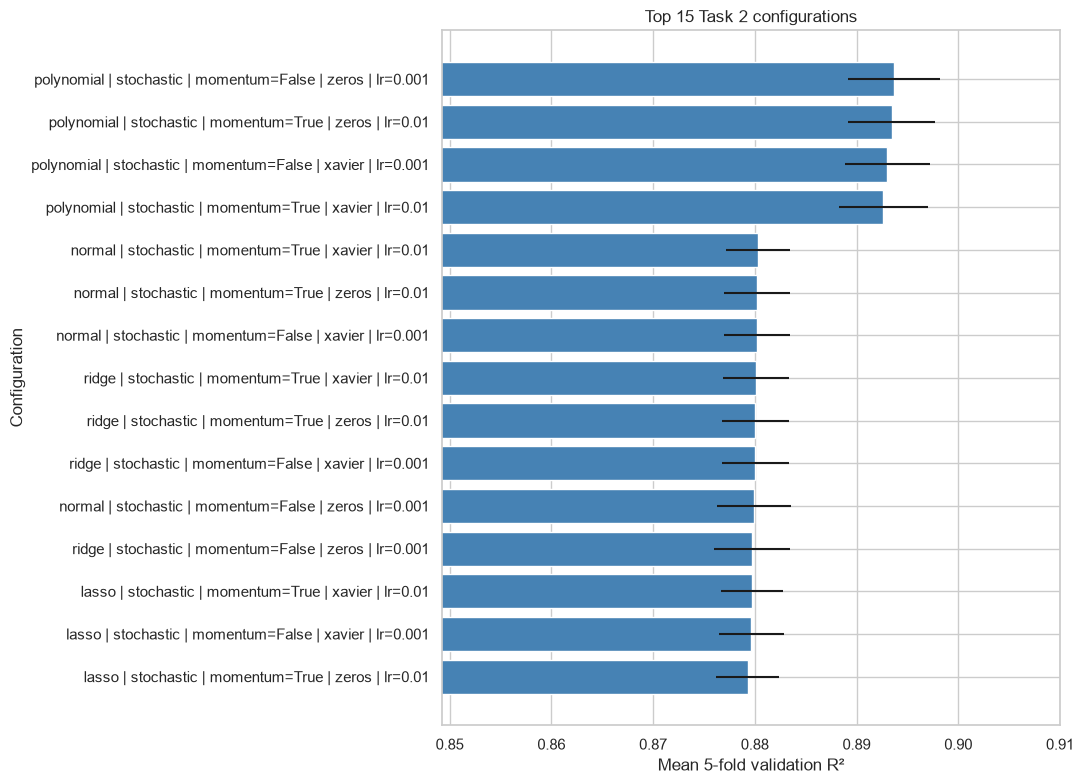

In [42]:
top_results = results.head(15).sort_values('cv_r2')
labels = top_results.apply(
    lambda row: (
        f"{row['model_type']} | {row['method']} | momentum={row['use_momentum']} | "
        f"{row['initialization']} | lr={row['learning_rate']:g}"
    ),
    axis=1,
)

plt.figure(figsize=(11, 8))
plt.barh(labels, top_results['cv_r2'], xerr=top_results['cv_r2_std'], color='steelblue')
plt.xlabel('Mean 5-fold validation R²')
plt.ylabel('Configuration')
plt.title('Top 15 Task 2 configurations')
plt.xlim(max(0, top_results['cv_r2'].min() - 0.03), 0.91)
plt.tight_layout()
plt.show()

### 4.3 Best model and held-out test performance

In [43]:
best_config = summary['best_config']
test_metrics = summary['test_metrics']

best_model_table = pd.DataFrame([{
    'model_type': best_config['model_type'],
    'regularization': best_config['regularization'],
    'momentum': best_config['use_momentum'],
    'method': best_config['method'],
    'initialization': best_config['initialization'],
    'learning_rate': best_config['learning_rate'],
    'cv_mse_log': best_config['cv_mse'],
    'cv_r2_log': best_config['cv_r2'],
    'test_mse_log': test_metrics['test_mse_log'],
    'test_r2_log': test_metrics['test_r2_log'],
    'test_rmse_price': test_metrics['test_rmse_price'],
    'test_r2_price': test_metrics['test_r2_price'],
}])
display(best_model_table.style.format({
    'learning_rate': '{:.4g}',
    'cv_mse_log': '{:.6f}', 'cv_r2_log': '{:.6f}',
    'test_mse_log': '{:.6f}', 'test_r2_log': '{:.6f}',
    'test_rmse_price': '{:,.2f}', 'test_r2_price': '{:.6f}',
}))

,model_type,regularization,momentum,method,initialization,learning_rate,cv_mse_log,cv_r2_log,test_mse_log,test_r2_log,test_rmse_price,test_r2_price
0,polynomial,normal,False,stochastic,zeros,0.001,0.060138,0.893693,0.056082,0.896979,"157,557.45",0.883156


In [33]:
# Re-create only the untouched test split so we can visualize saved-model predictions.
NUMERIC = ['year', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats']
CATEGORICAL = ['brand', 'fuel', 'seller_type', 'transmission']
X = df[NUMERIC + CATEGORICAL]
y_log = np.log(df['selling_price'].astype(float))
_, X_test, _, y_test_log = train_test_split(
    X, y_log, test_size=0.20, random_state=42
)

X_test_transformed = bundle['preprocessor'].transform(X_test)
X_test_with_intercept = np.column_stack([
    np.ones(X_test_transformed.shape[0]), X_test_transformed
])
predicted_log_price = (
    bundle['model'].predict(X_test_with_intercept) * bundle['target_scale']
    + bundle['target_mean']
)
actual_price = np.exp(y_test_log.to_numpy())
predicted_price = np.exp(predicted_log_price)

# Independent checks against the metrics saved by a2_mlflow.py.
assert np.isclose(mean_squared_error(y_test_log, predicted_log_price), test_metrics['test_mse_log'])
assert np.isclose(r2_score(y_test_log, predicted_log_price), test_metrics['test_r2_log'])
print('Saved model and test metrics reproduced successfully.')

Saved model and test metrics reproduced successfully.


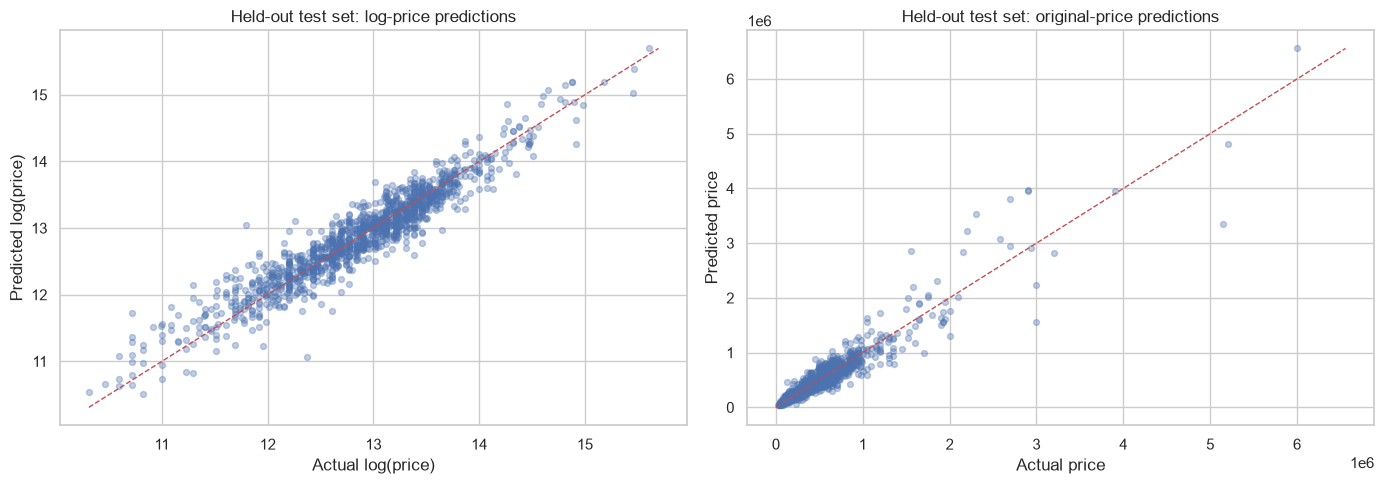

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_log, predicted_log_price, alpha=0.35, s=18)
log_low = min(y_test_log.min(), predicted_log_price.min())
log_high = max(y_test_log.max(), predicted_log_price.max())
axes[0].plot([log_low, log_high], [log_low, log_high], 'r--', linewidth=1)
axes[0].set_xlabel('Actual log(price)')
axes[0].set_ylabel('Predicted log(price)')
axes[0].set_title('Held-out test set: log-price predictions')

axes[1].scatter(actual_price, predicted_price, alpha=0.35, s=18)
price_high = max(actual_price.max(), predicted_price.max())
axes[1].plot([0, price_high], [0, price_high], 'r--', linewidth=1)
axes[1].set_xlabel('Actual price')
axes[1].set_ylabel('Predicted price')
axes[1].set_title('Held-out test set: original-price predictions')

plt.tight_layout()
plt.show()

### 4.4 Feature importance based on coefficients

The function from Task 1 ranks the features using the absolute size of each coefficient, while the bar direction shows whether the coefficient is positive or negative. The numeric and polynomial numeric features were standardized, but the one-hot encoded categorical columns remain binary (0 or 1). Therefore, I use this graph as a rough interpretation of the model rather than a perfect comparison between every feature. A positive coefficient is connected with a higher predicted log price, while a negative coefficient is connected with a lower predicted log price, assuming the other transformed features stay the same.

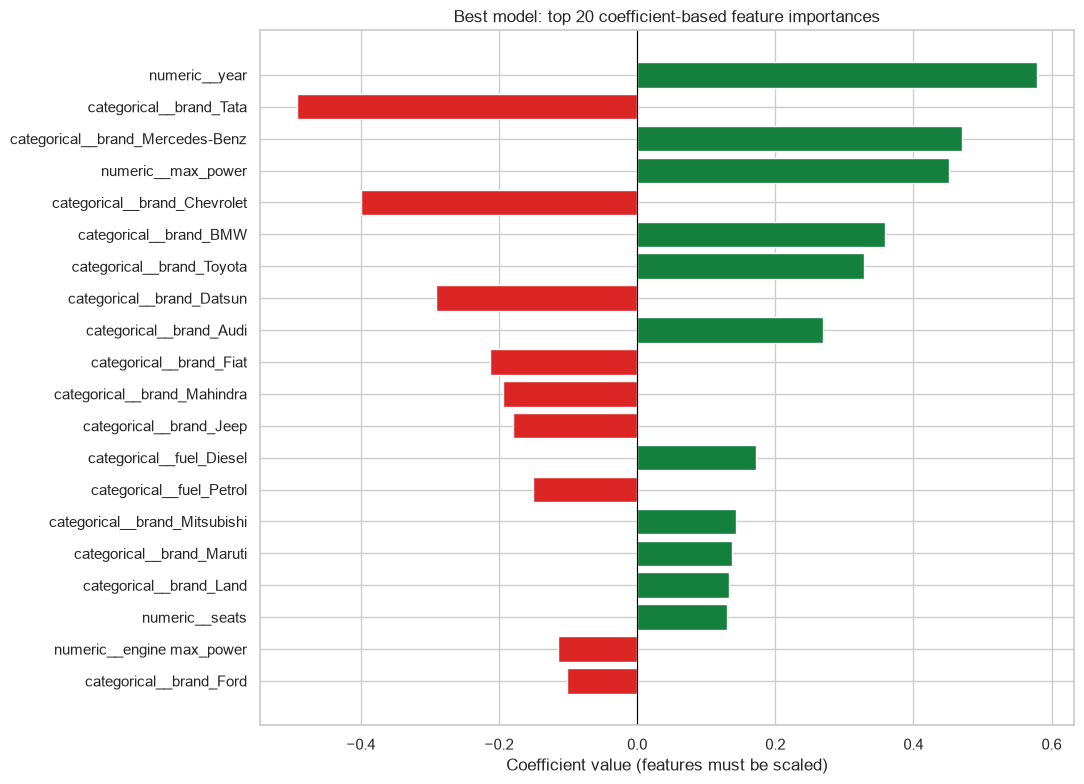

In [35]:
fig, ax = plt.subplots(figsize=(11, 8))
bundle['model'].plot_feature_importance(
    bundle['feature_names'], top_n=20, ax=ax
)
ax.set_title('Best model: top 20 coefficient-based feature importances')
plt.tight_layout()
plt.show()

### 4.5 MLflow evidence and screenshots

All 144 cross-validation experiments are stored in `data/a2_mlflow.db`. From the project root, start the MLflow interface with:

```bash
venv/bin/mlflow ui --backend-store-uri sqlite:///data/a2_mlflow.db --port 5000
```

Then open [http://127.0.0.1:5000](http://127.0.0.1:5000). Capture (1) the runs table sorted by `cv_r2` descending and (2) the best run's parameters and metrics. Save them as `docs/a2_mlflow_runs.png` and `docs/a2_mlflow_best_run.png`; the next cell will display them.

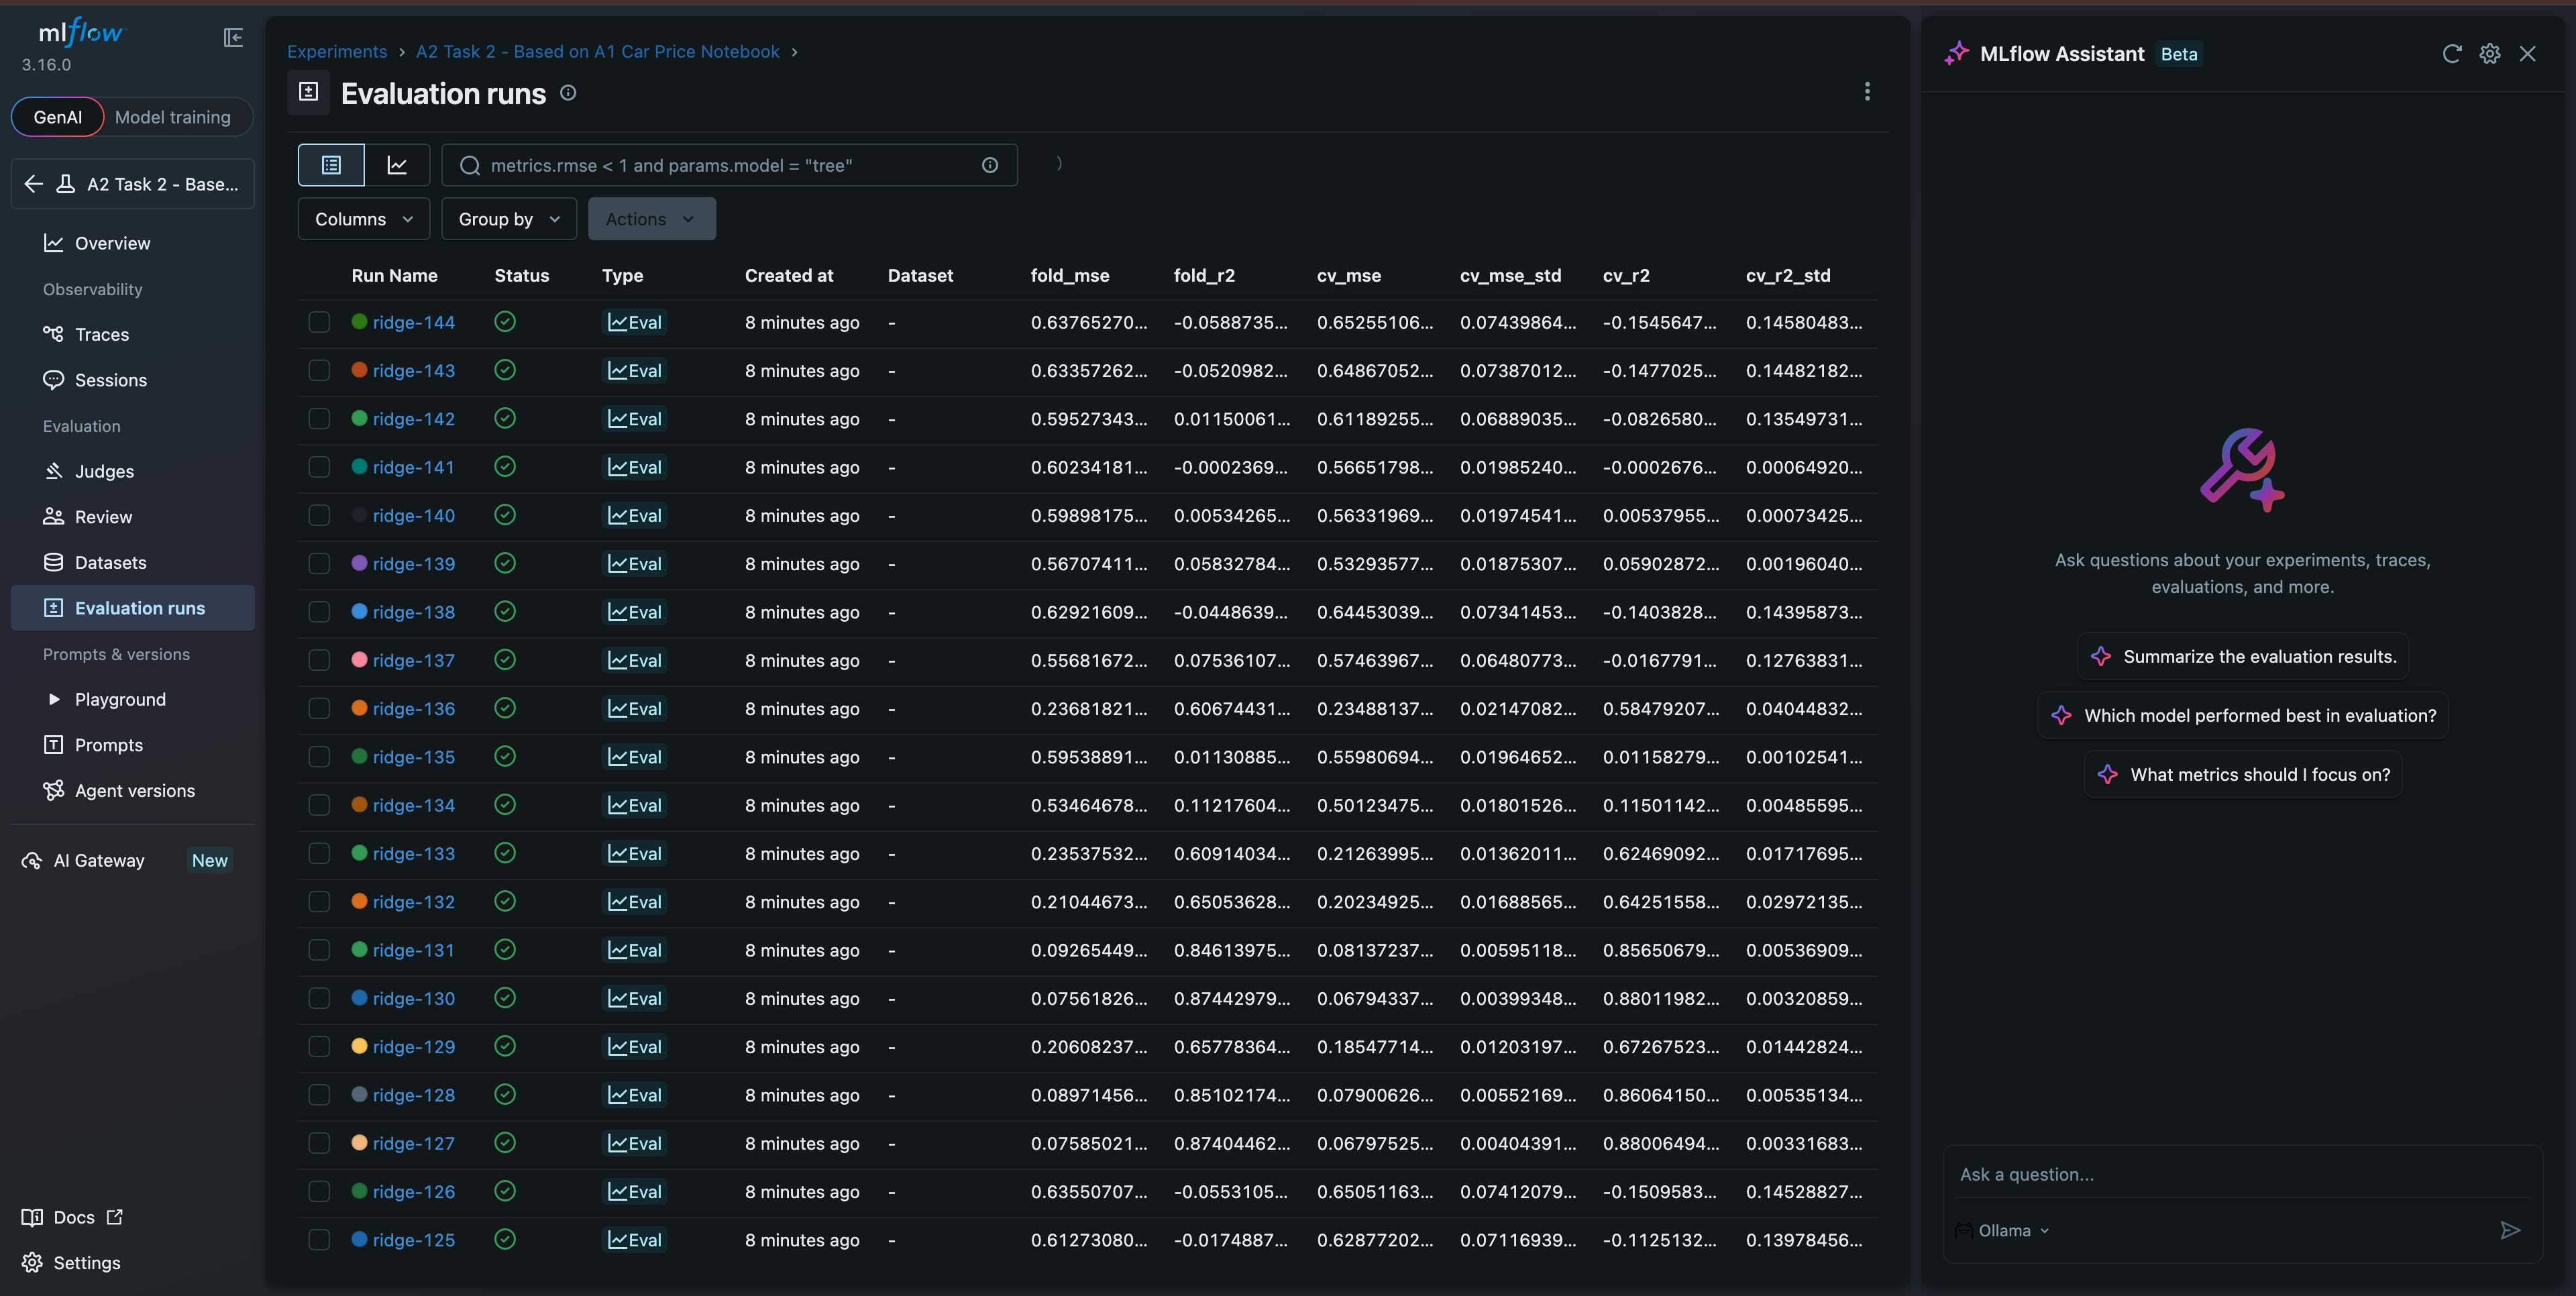

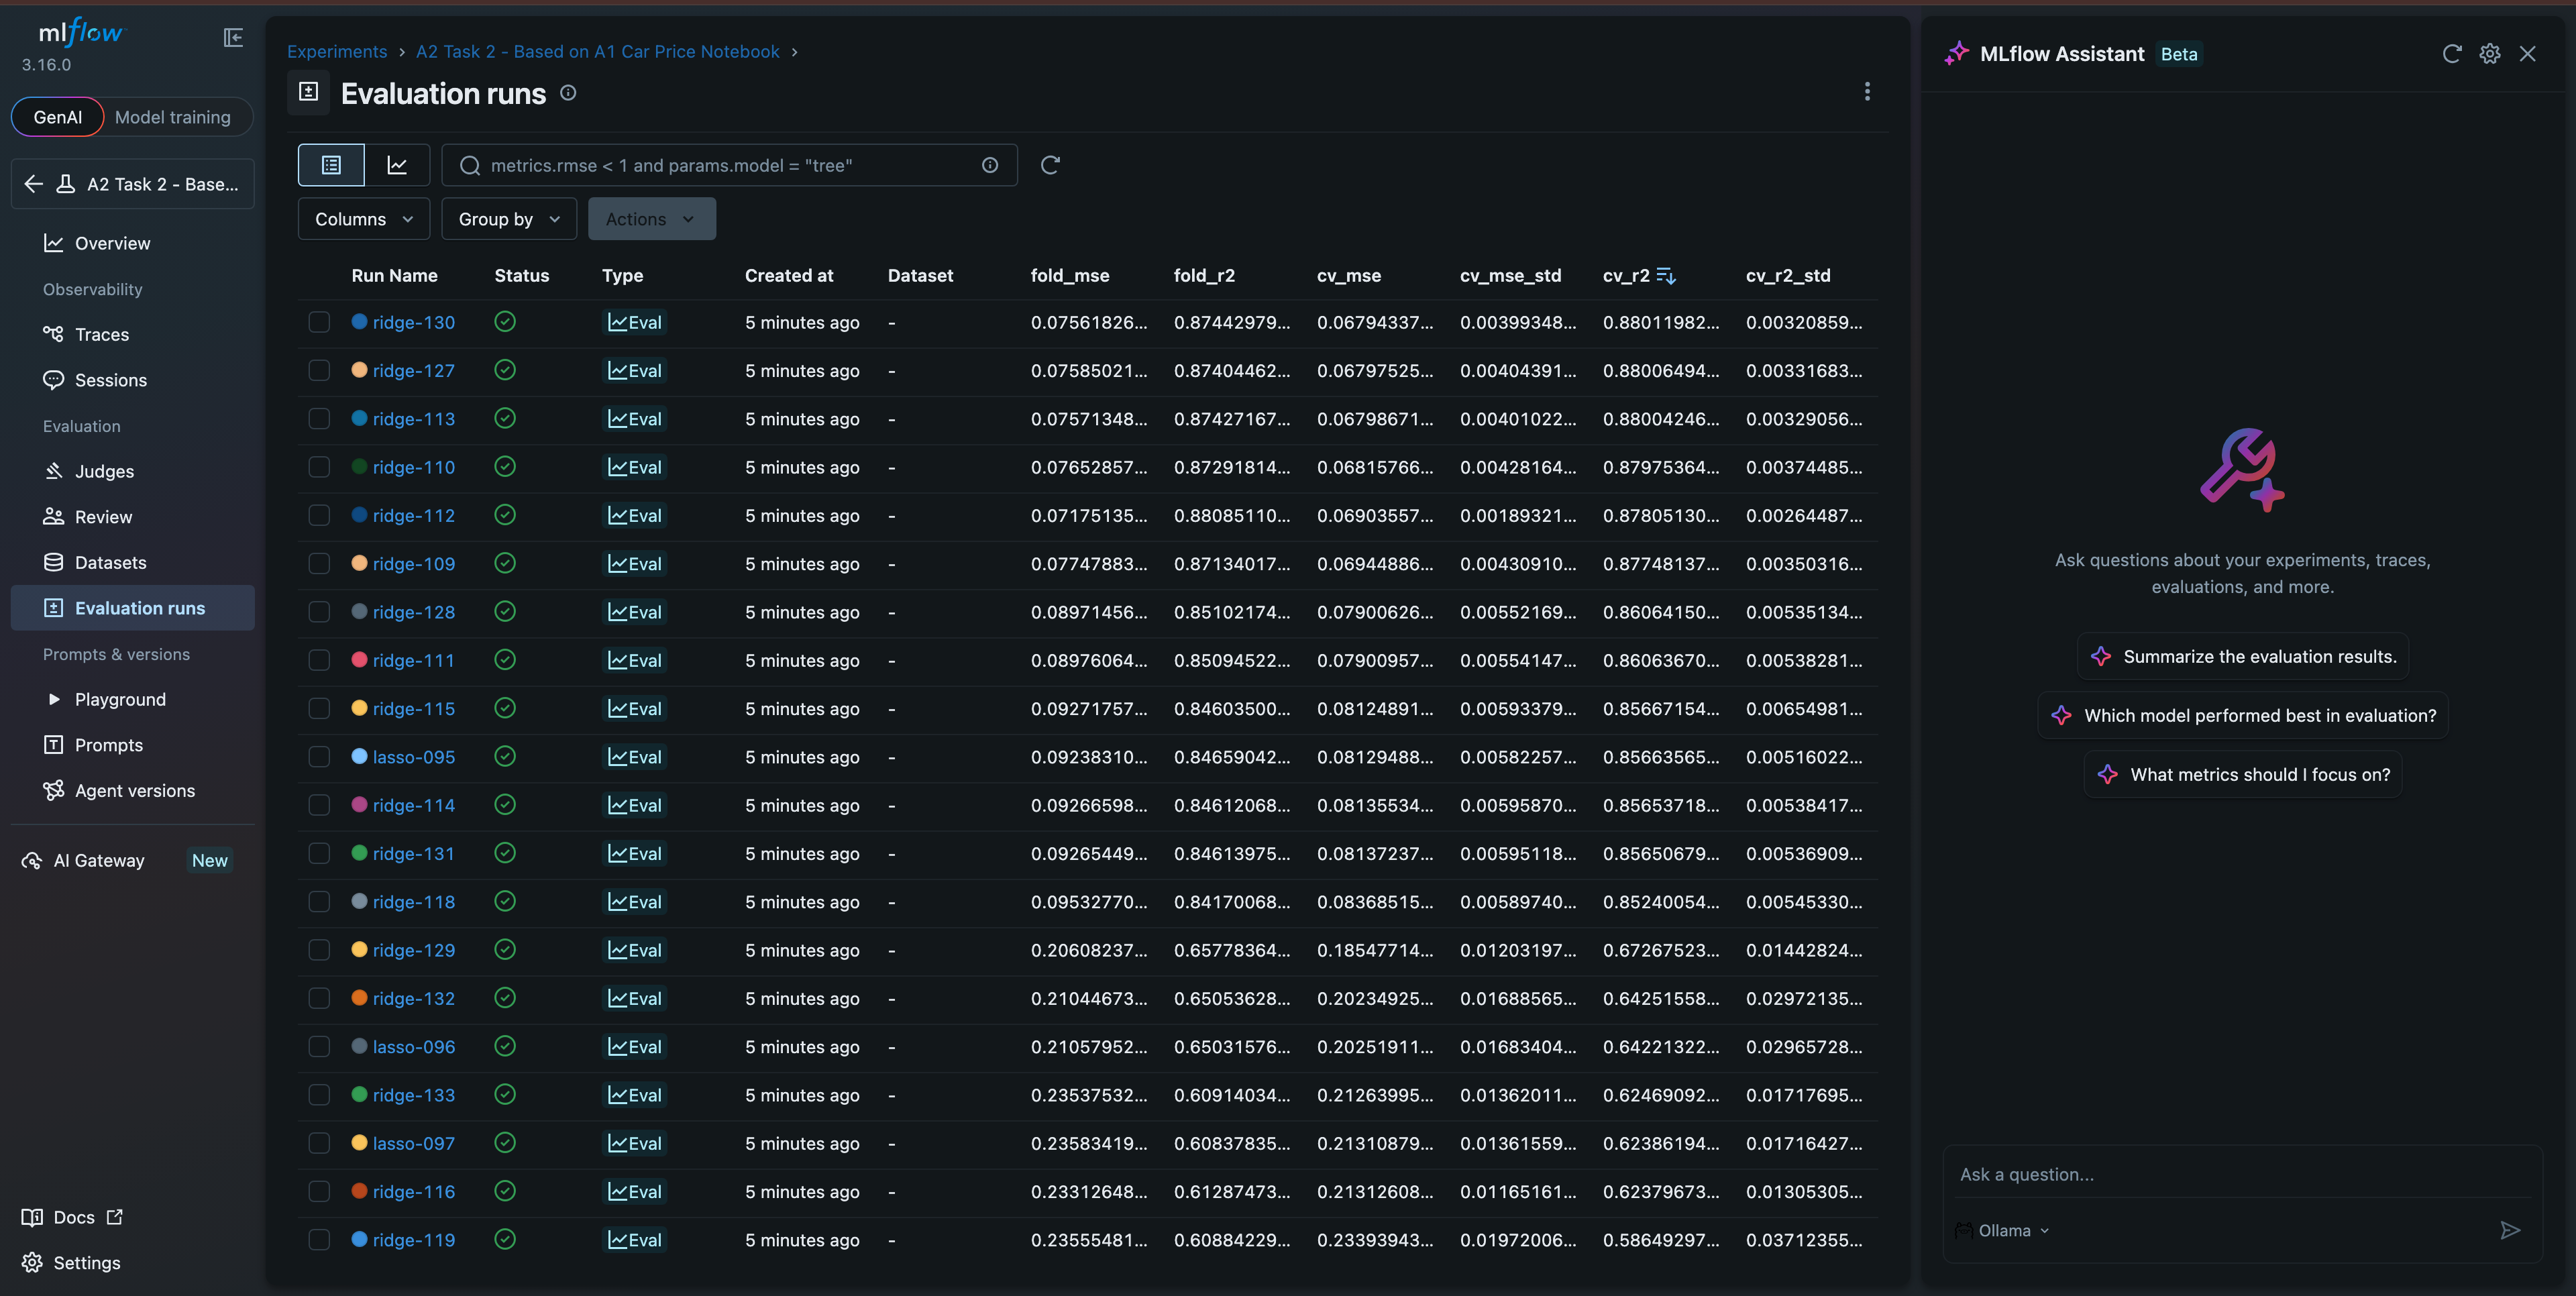

In [37]:
from IPython.display import Image, display

screenshot_paths = [
    PROJECT_ROOT / 'docs' / 'a2_mlflow_runs.png',
    PROJECT_ROOT / 'docs' / 'a2_mlflow_best_run.png',
]
for screenshot_path in screenshot_paths:
    if screenshot_path.exists():
        display(Image(filename=str(screenshot_path)))
    else:
        print(f'Add screenshot: {screenshot_path}')

## 5. Report and findings

### Experiment setup

For this assignment, I kept the same cleaned dataset and log-transformed selling price from Assignment 1. I compared ordinary linear regression (called `normal` in my experiment), polynomial regression, lasso, and ridge. For each model, I also tested momentum on and off, three gradient descent methods, zero and Xavier initialization, and three learning rates. This gave me 144 configurations in total. I used five-fold cross-validation only on the training set and recorded the runs in MLflow. The test set was kept separate until I selected the best configuration.

### Best cross-validation result

The best configuration was **polynomial regression with no regularization**, **no momentum**, **stochastic gradient descent**, **zero initialization**, and a learning rate of **0.001**. Its mean cross-validation MSE was **0.060138** and its mean cross-validation R² was **0.893693**. Both values are calculated using `log(selling_price)`, because that is the target used to train the model.

The best ordinary linear regression, ridge, and lasso runs had cross-validation R² scores of about **0.8803**, **0.8801**, and **0.8797**, respectively. The best polynomial result was slightly higher, so the extra squared and interaction terms helped this dataset when the optimizer settings were suitable.

### Test-set result

After choosing the best configuration, I fitted it again using the full training set and evaluated it once on the test set. The results were:

| Scale | MSE | RMSE | R² |
|---|---:|---:|---:|
| Log selling price | 0.056082 | 0.236817 | 0.896979 |
| Original selling price (rupees) | 24,824,350,541.55 | 157,557.45 | 0.883156 |

The main R² I report for Task 2 is **0.896979**, because the model was trained and evaluated using the log-price target. The R² becomes **0.883156** after I convert the predictions and actual values back to rupees. These two scores are different because exponentiation is a nonlinear transformation; they are not two calculations of R² on the same scale. The test log R² is also close to the cross-validation R² of 0.893693, so the selected model performed similarly on unseen data.

### What I observed

Stochastic gradient descent produced the best run. The best mini-batch configuration reached an R² of **0.867600**, while the best batch configuration reached **0.375067** under the same 12-epoch limit. However, stochastic training updates the weights once for every row, so it performs many more updates per epoch. Therefore, I cannot conclude that stochastic gradient descent is always better; it was better under the training budget used in this experiment.

Momentum did not improve the final selected model. The strongest run without momentum had an R² of **0.893693**, compared with **0.893437** for the strongest run with momentum. Zero and Xavier initialization were also very close in their best runs, with R² values of **0.893693** and **0.893027**. This suggests that the optimizer and learning rate affected the result more than the initialization choice in this experiment.

From the coefficient plot, model year and maximum power were among the strongest numeric features. Several brand columns also had large positive or negative coefficients. I interpret this carefully because the numeric and polynomial numeric features were standardized, while the one-hot brand and fuel columns were still binary. Also, coefficients show relationships learned by the model, not proof that a feature directly causes a price change.

Overall, polynomial regression gave the best result among the models required for Task 2. It explained about **89.7% of the variation in log selling price** on the test set. The experiment also showed me that a model name alone is not enough to decide which model is best, because the gradient method, learning rate, momentum, and initialization can change the result.